## IEMOCAP Baselines: Diagnostic Analysis
This notebook ingests the output CSVs generated by the `extract_diagnostics.py` script. It provides a comprehensive analysis of the model's predictive capabilities across the various testing modes (`flat8`, `stage1`, `stage2`), including Unweighted Average Recall (UAR), confusion matrices, and hidden state dimensionality reduction using UMAP.

In [3]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, confusion_matrix
import umap

# Configure standard seaborn plot aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# =====================================================================
# 1. PATH CONFIGURATIONS
# =====================================================================
# Specify the active tracking mode: 'flat8', 'stage1', or 'stage2'
MODE = 'flat8'

# Set the correct absolute path to your generated diagnostic results CSV
RESULTS_CSV_PATH = rf"d:\Resfes\Project\Ser\data\DataFrames\{MODE}_evaluation_results.csv"

# Load the diagnostic results
print(f"[INFO] Loading diagnostic results for mode: {MODE.upper()}")
if not os.path.exists(RESULTS_CSV_PATH):
    raise FileNotFoundError(f"Diagnostic results not found at: {RESULTS_CSV_PATH}")
    
df_results = pd.read_csv(RESULTS_CSV_PATH)
print(f"[SUCCESS] Loaded {len(df_results)} prediction records.")

[INFO] Loading diagnostic results for mode: FLAT8
[SUCCESS] Loaded 7527 prediction records.


## 1. Core Performance Metrics
Calculate the primary evaluation metrics. **UAR (Unweighted Average Recall)** is the standard benchmark for IEMOCAP due to its high class imbalance.

In [7]:
# =====================================================================
# 2. CALCULATE METRICS
# =====================================================================
# Extract true labels and predictions
y_true = df_results['True_Label'].tolist()
y_pred = df_results['Pred_Label'].tolist()

# 1. WAR (Weighted Average Recall) - Equivalent to standard Accuracy
war = accuracy_score(y_true, y_pred)

# 2. UAR (Unweighted Average Recall) - Macro-averaged recall across all classes
uar = recall_score(y_true, y_pred, average='macro', zero_division=0.0)

# 3. Macro F1-Score
ma_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0.0)

print(f"{'='*50}")
print(f"🏆 {MODE.upper()} OVERALL DIAGNOSTIC METRICS")
print(f"{'='*50}")
print(f"WAR (Accuracy) : {war:.4f}")
print(f"UAR            : {uar:.4f}")
print(f"Macro F1-Score : {ma_f1:.4f}")
print(f"{'='*50}\n")

# Display detailed per-class metrics
# Note: Ensure the target names map exactly to the dictionary used during extraction.
if MODE == 'flat8':
    target_names = ['Neutral', 'Happiness', 'Excitement', 'Sadness', 'Anger', 'Frustration', 'Fear', 'Surprise']
elif MODE == 'stage1':
    target_names = ['Positive', 'Neutral', 'Negative']
elif MODE == 'stage2':
    target_names = ['Anger', 'Sadness', 'Fear', 'Frustration']

print("[INFO] Per-Class Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0.0))

🏆 FLAT8 OVERALL DIAGNOSTIC METRICS
WAR (Accuracy) : 0.6126
UAR            : 0.5020
Macro F1-Score : 0.5154

[INFO] Per-Class Classification Report:
              precision    recall  f1-score   support

     Neutral       0.56      0.72      0.63      1708
   Happiness       0.43      0.40      0.42       595
  Excitement       0.61      0.63      0.62      1041
     Sadness       0.72      0.76      0.74      1084
       Anger       0.63      0.73      0.68      1103
 Frustration       0.67      0.45      0.54      1849
        Fear       0.83      0.25      0.38        40
    Surprise       0.44      0.07      0.11       107

    accuracy                           0.61      7527
   macro avg       0.61      0.50      0.52      7527
weighted avg       0.62      0.61      0.60      7527



## 2. Confusion Matrix Analysis
Visualize the confusion matrix to identify specific class overlaps and error patterns.

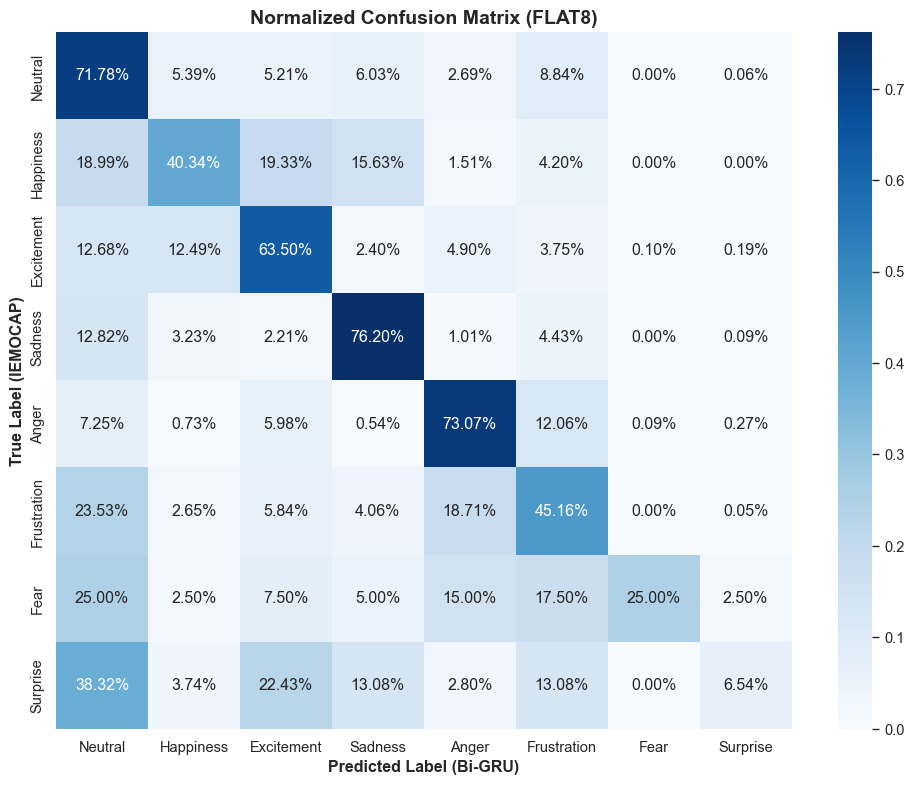

In [8]:
# =====================================================================
# 3. PLOT CONFUSION MATRIX
# =====================================================================
# Compute a row-normalized confusion matrix (showing percentages)
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", 
            xticklabels=target_names, 
            yticklabels=target_names)

plt.title(f"Normalized Confusion Matrix ({MODE.upper()})", fontsize=14, fontweight='bold')
plt.ylabel("True Label (IEMOCAP)", fontweight='bold')
plt.xlabel("Predicted Label (Bi-GRU)", fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Hidden State Dimensionality Reduction (UMAP)
Project the hidden states extracted from the final layer of the Bi-GRU into a 2D space to visualize cluster separability.

[INFO] Looking for binary hidden states at: d:\Resfes\Project\Ser\data\Embeddings\flat8_bigru_hidden_states.npy
[SUCCESS] Loaded 7527 hidden states vectors.
[INFO] Fitting UMAP on 3000 samples... (This may take a moment)


d:\Resfes\Project\Ser\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


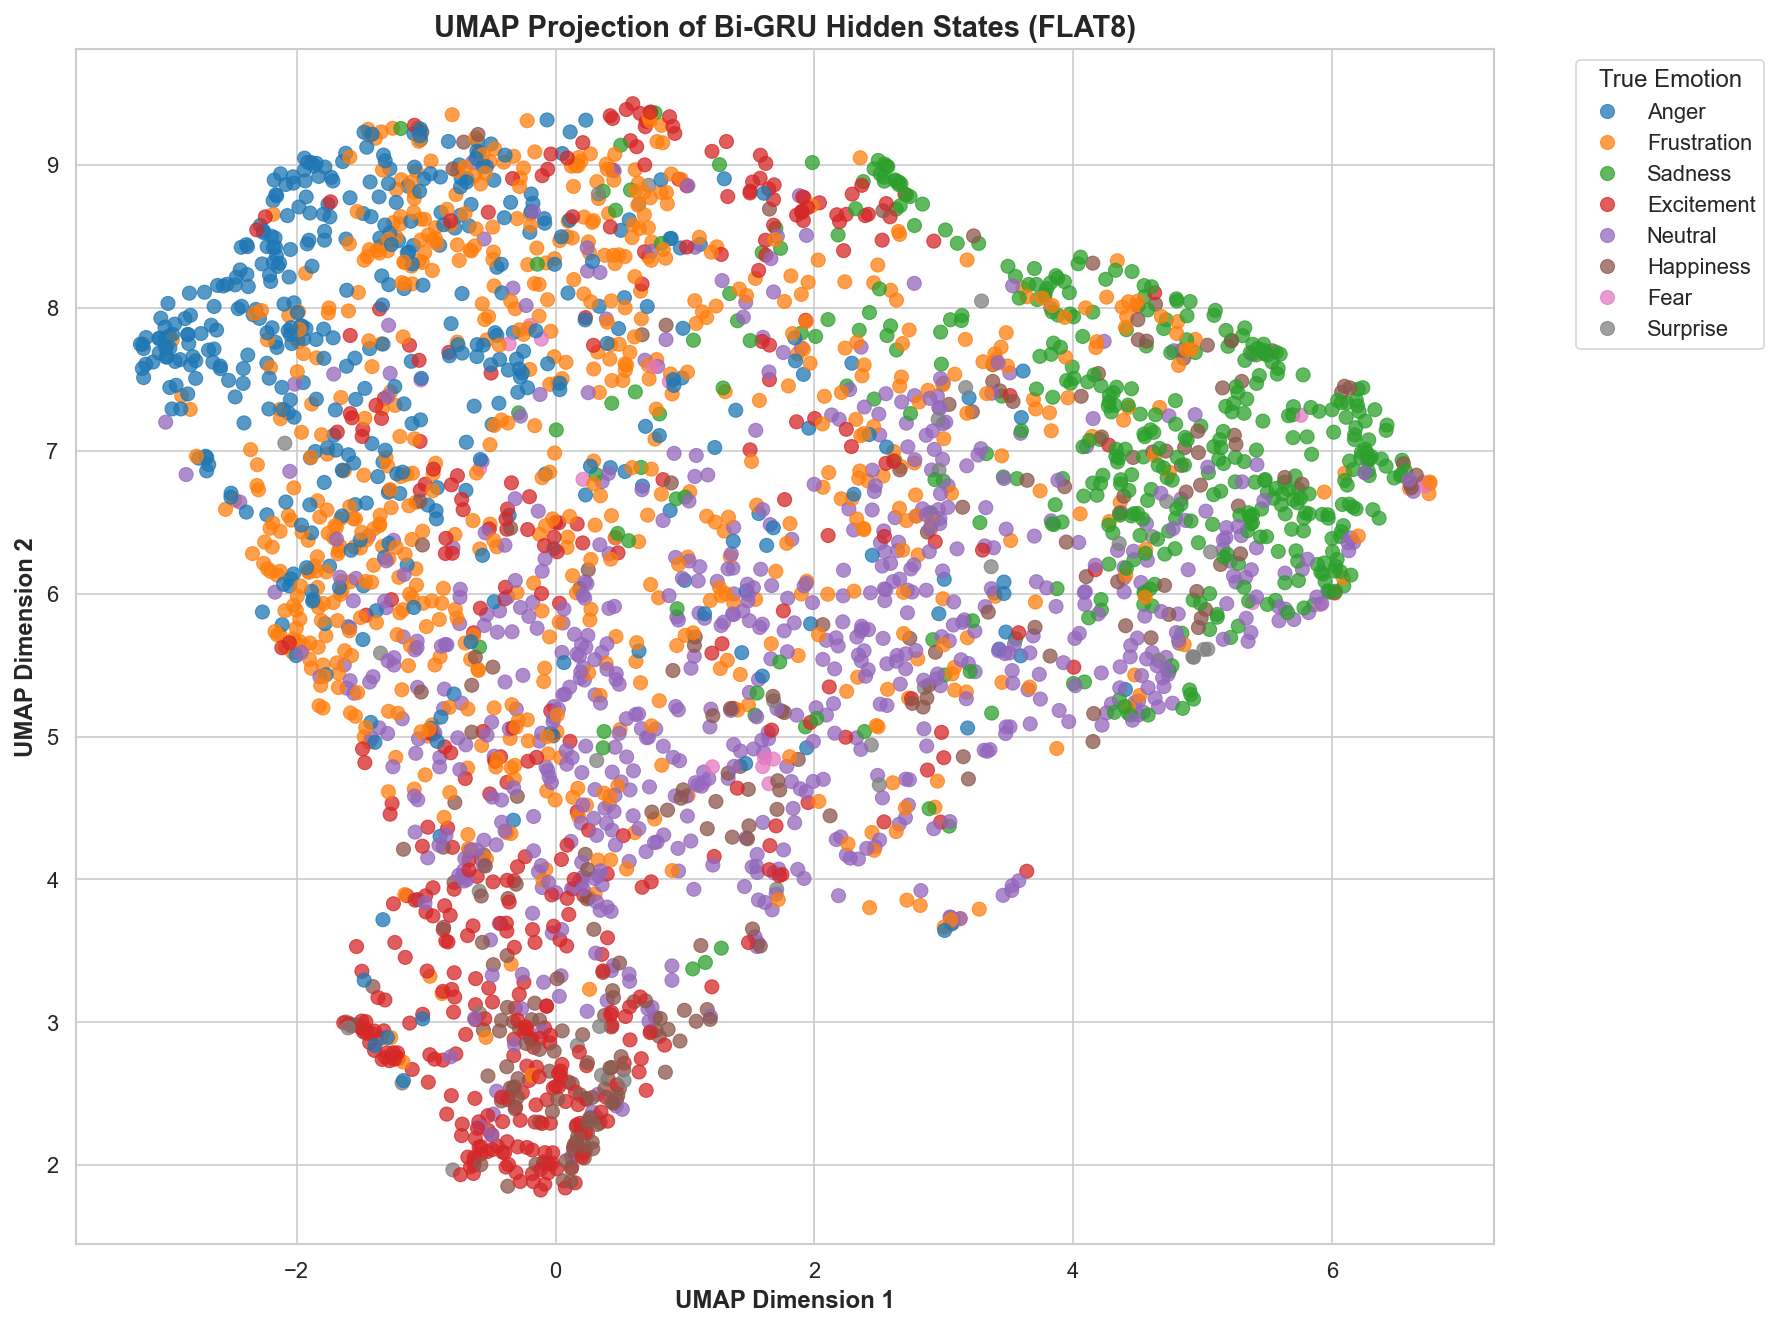

In [11]:
# =====================================================================
# 4. UMAP CLUSTER VISUALIZATION (BINARY .NPY OPTIMIZED)
# =====================================================================
# Construct path to the binary hidden states array saved by the extractor
NPY_PATH = rf"d:\Resfes\Project\Ser\data\Embeddings\{MODE}_bigru_hidden_states.npy"

print(f"[INFO] Looking for binary hidden states at: {NPY_PATH}")

if os.path.exists(NPY_PATH):
    # Load the pre-extracted hidden states directly into memory
    hidden_states = np.load(NPY_PATH)
    
    # Verify strict length parity between CSV records and numpy hidden states
    assert len(hidden_states) == len(df_results), (
        f"[ERROR] Row mismatch! CSV has {len(df_results)} rows, "
        f"but .npy hidden states file has {len(hidden_states)} vectors."
    )
    
    print(f"[SUCCESS] Loaded {len(hidden_states)} hidden states vectors.")
    
    # 1. GENERATE INDEX-ALIGNED SAMPLES
    # Limit to a subset (max 3000) for performance and visual clarity on the scatter plot
    sample_size = min(3000, len(df_results))
    
    # Use a fixed random seed to ensure visual replication of the UMAP cluster shape
    rng = np.random.RandomState(42)
    sample_indices = rng.choice(len(df_results), size=sample_size, replace=False)
    
    # Slice BOTH the DataFrame and the Hidden States array with the exact same indices
    sample_df = df_results.iloc[sample_indices].copy()
    sample_hidden_states = hidden_states[sample_indices]
    
    # 2. RUN UMAP DIMENSIONALITY REDUCTION
    print(f"[INFO] Fitting UMAP on {sample_size} samples... (This may take a moment)")
    reducer = umap.UMAP(
        n_neighbors=15, 
        min_dist=0.1, 
        n_components=2, 
        random_state=42,
        n_jobs=-1 # Utilize all available CPU threads for calculation
    )
    embedding = reducer.fit_transform(sample_hidden_states)
    
    # 3. EXTRACT LABELS AND PLOT CLUSTERS
    labels = sample_df['True_Label'].tolist()
    label_names = [target_names[i] for i in labels]

    plt.figure(figsize=(12, 9), dpi=150)
    sns.scatterplot(
        x=embedding[:, 0], 
        y=embedding[:, 1], 
        hue=label_names, 
        palette="tab10", 
        s=45, 
        alpha=0.75,
        edgecolor=None
    )
    
    plt.title(f"UMAP Projection of Bi-GRU Hidden States ({MODE.upper()})", fontsize=14, fontweight='bold')
    plt.xlabel("UMAP Dimension 1", fontweight='bold')
    plt.ylabel("UMAP Dimension 2", fontweight='bold')
    plt.legend(title="True Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

else:
    print(f"[WARNING] Hidden states file not found at: {NPY_PATH}")
    print("Please make sure you have run your extraction pipeline successfully.")